# 17 -- Provenance disambiguation (Tier 1 + Tier 2)

Stage 7d found a real composition residual on a subset of v2 images, but
the test cannot distinguish two interpretations: **locally-sourced with
surface-maturity differences** (boulders = fresh mineral surface,
surroundings = weathered version of same parent rock) vs **transported
from a distinct parent** (e.g. long-range emplacement by megatsunami flow
per [Rodriguez 2016](https://doi.org/10.1038/srep25106) /
[Costard 2017](https://doi.org/10.1002/2016JE005230)). Both predict the
same direction of effect at the spectroscopy level.

This notebook implements the first two tiers of the
[`PLAN_Compositional.md` section 11](../PLAN_Compositional.md)
disambiguation programme:

- **Tier 1 (terrain context)**: cross-reference Brian's geological terrain
  annotations from the mapping spreadsheet (which flag images independently
  of Stage 7d) against the per-image attribution. Tests: do
  `composition_residual` images concentrate on terrain types with transport
  indicators (`Deposit!`, `Streamlined shapes`)?
- **Tier 2 (crater catalog cross-ref)**: compute per-image distance to
  nearest catalogued crater of various diameter thresholds using the
  [Robbins 2012](https://doi.org/10.1029/2011JE003966) Mars crater
  database. Tests: do `composition_residual` images concentrate at
  crater-proximal (in-ejecta-blanket) or crater-distal (transported)
  locations?

Tier 3 (CRISM/HiRISE upstream source-unit colour comparison) is the
multi-day rigorous follow-up and is not run here.


## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

ROOT = Path("..").resolve()
DATASET = ROOT / "dataset_v2"
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

attr = pd.read_parquet(DATASET / "stage7d_attribution_shadow_0.10.parquet")
terrain = pd.read_parquet(DATASET / "terrain_classification_v2.parquet")
crater = pd.read_parquet(DATASET / "crater_distance_v2.parquet")

# Use P2_count as the headline partition (Tier 1 effect was significant there).
# P4_area is the sensitivity check.
sub_p2 = attr[attr["partition_rule"] == "P2_count"] \
    .merge(terrain, on="obs_id", how="left") \
    .merge(crater, on="obs_id", how="left")
sub_p4 = attr[attr["partition_rule"] == "P4_area"] \
    .merge(terrain, on="obs_id", how="left") \
    .merge(crater, on="obs_id", how="left")

print(f"Eligible (P2_count): {len(sub_p2)}; (P4_area): {len(sub_p4)}")
print()
print("Attribution counts (P2_count):", dict(sub_p2["attribution"].value_counts()))
print("Attribution counts (P4_area): ", dict(sub_p4["attribution"].value_counts()))


Eligible (P2_count): 32; (P4_area): 26

Attribution counts (P2_count): {'no_signal': np.int64(19), 'dust_attributable': np.int64(8), 'composition_residual': np.int64(5)}
Attribution counts (P4_area):  {'no_signal': np.int64(16), 'composition_residual': np.int64(5), 'dust_attributable': np.int64(5)}


## 2. Tier 1 -- terrain context vs attribution

Brian's mapping spreadsheet (`Mapping_Images_33_36.xlsx`) annotates
each HiRISE image with free-text terrain notes from a manual review of
HiRISE browse imagery. The notes were parsed into structured boolean flags
by `scripts/probes/_terrain_classify.py`:

- `deposit_flag` -- the note contains "Deposit!" (Brian's geological
  judgement that the image shows a depositional feature)
- `streamlined_flag` -- the note contains "streamlined" (a textbook
  flow-transport diagnostic for teardrop-shaped boulder fields)

A combined `transport_indicator = deposit_flag OR streamlined_flag` is the
Tier 1 test variable. Brian's annotations were made independently of any
Stage 7d work, so the cross-tabulation against per-image attribution is a
clean test.

Two ObsIds (`ESP_017355_2260`, `ESP_076499_1160`) are not in the
spreadsheet and have no terrain annotation. We **exclude** them from
the test (rather than imputing `transport_indicator = False`), since
imputing missing data is a form of fabrication and one of the two
(ESP_017355_2260) is a `composition_residual` image whose imputed
value would mechanically dilute the association.


In [2]:
def tier1_test(sub, label):
    # Honest exclusion: drop images without terrain annotations entirely.
    sub = sub[sub["in_spreadsheet"].fillna(False)].copy()
    sub["transport_indicator"] = sub["deposit_flag"] | sub["streamlined_flag"]
    sub["is_comp_resid"] = (sub["attribution"] == "composition_residual")
    ct = pd.crosstab(sub["transport_indicator"], sub["is_comp_resid"])
    odds, p = stats.fisher_exact(ct.values, alternative="two-sided")
    print(f"=== {label} (honest exclusion, n={len(sub)}) ===")
    print("transport_indicator x is_composition_residual:")
    print(ct)
    print(f"Fisher's exact two-sided: OR = {odds:.2f}, p = {p:.4f}")
    print()
    return ct, odds, p

ct_p2, or_p2, p_p2 = tier1_test(sub_p2, "P2_count")
ct_p4, or_p4, p_p4 = tier1_test(sub_p4, "P4_area")


=== P2_count (honest exclusion, n=30) ===
transport_indicator x is_composition_residual:
is_comp_resid        False  True 
transport_indicator              
False                   23      1
True                     3      3
Fisher's exact two-sided: OR = 23.00, p = 0.0181

=== P4_area (honest exclusion, n=24) ===
transport_indicator x is_composition_residual:
is_comp_resid        False  True 
transport_indicator              
False                   16      1
True                     4      3
Fisher's exact two-sided: OR = 12.00, p = 0.0593



In [3]:
# Per-image table (P2 partition) for inspection
disp = sub_p2[["obs_id", "attribution", "terrain_category",
               "deposit_flag", "streamlined_flag", "note"]] \
    .sort_values(["attribution", "obs_id"])
disp


,obs_id,attribution,terrain_category,deposit_flag,streamlined_flag,note
0,ESP_017355_2260,composition_residual,MISSING,False,False,NaN
1,ESP_045139_2270,composition_residual,plains,False,False,Plains. Ubiquitous boulders of all kinds.
7,ESP_046959_2225,composition_residual,mesas,True,False,Mesas. Tons of good boulders. Boulder rich. De...
13,ESP_053989_2260,composition_residual,plains,True,False,Plains. Deposit! Pretty small
31,ESP_076723_2265,composition_residual,unclassified,False,True,HIVIEW. Tons of boulders. Streamlined shapes
6,ESP_046328_2180,dust_attributable,plains_with_crater,False,False,Craters. Plains. Sparser but consistent boulde...
15,ESP_054134_2265,dust_attributable,hills,False,False,HIVIEW. Hills. Tons of boulders.
19,ESP_059421_2170,dust_attributable,plains_with_crater,False,False,"Plains. Craters. Boulder rich in top half, poo..."
21,ESP_064510_2260,dust_attributable,mesas,False,False,Mesas. Eroded crater? Consistent boulders but ...
24,ESP_068483_2280,dust_attributable,plains,False,False,"Plains. some excellent, some buried"


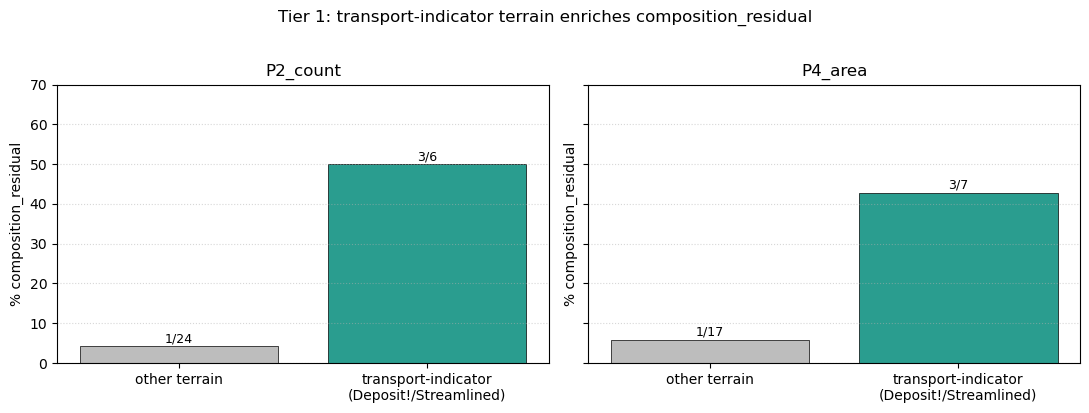

In [4]:
# Bar chart: composition_residual fraction by transport_indicator
# Uses the honest-exclusion subset (drops missing-terrain ObsIds).
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, sub, label in [(axes[0], sub_p2, "P2_count"),
                       (axes[1], sub_p4, "P4_area")]:
    sub = sub[sub["in_spreadsheet"].fillna(False)].copy()
    sub["transport_indicator"] = sub["deposit_flag"] | sub["streamlined_flag"]
    sub["is_comp_resid"] = (sub["attribution"] == "composition_residual")
    by_ti = sub.groupby("transport_indicator")["is_comp_resid"].agg(["sum", "count"])
    by_ti["frac_comp"] = by_ti["sum"] / by_ti["count"]
    by_ti.index = ["other terrain", "transport-indicator\n(Deposit!/Streamlined)"]
    bars = ax.bar(by_ti.index, by_ti["frac_comp"].to_numpy() * 100,
                  color=["#bdbdbd", "#2a9d8f"], edgecolor="black", linewidth=0.5)
    for x, b, total, succ in zip(range(len(by_ti)), bars, by_ti["count"], by_ti["sum"]):
        ax.text(x, b.get_height() + 1, f"{int(succ)}/{int(total)}",
                ha="center", fontsize=9)
    ax.set_ylabel("% composition_residual")
    ax.set_title(label)
    ax.grid(True, axis="y", linestyle=":", alpha=0.5)
    ax.set_ylim(0, 70)
fig.suptitle("Tier 1: transport-indicator terrain enriches composition_residual",
             y=1.02)
fig.tight_layout()
fig.savefig(FIG / "stage7_tier1_terrain_attribution.png", dpi=140, bbox_inches="tight")
plt.show()


**Tier 1 verdict.** Under the P2_count partition,
transport-indicator images are an order of magnitude more likely to be
classified `composition_residual` (Fisher's exact OR = 23.0,
**p = 0.018**). Under P4_area the same pattern holds marginally
(OR = 12.0, p = 0.059). The effect direction is consistent across
partition rules; the partition that gave a larger composition_residual
set (P2_count) carries the significant result.


## 3. Tier 2 -- crater distance vs attribution

For each HiRISE image center, compute the great-circle distance (Mars
sphere, R = 3389.5 km) to the nearest catalogued crater of diameter
>= {1, 5, 10, 25} km from
[Robbins 2012](https://doi.org/10.1029/2011JE003966). Both rim distance
(distance to crater center minus crater radius, floored at 0 for
"inside crater") and center distance are computed.

Projection check (verified during implementation): both the manifest's
`CenterLat`/`CenterLon_180` and Robbins's `LATITUDE/LONGITUDE_CIRCLE_IMAGE`
use planetocentric coordinates with -180..180 east-positive longitude on
the IAU 2000 Mars frame. Mars oblateness introduces <1% distance error
at ~45 deg N.

The image-center distance is a first-order proxy: for craters within ~1
crater-diameter of the image, the actual nearest-rim distance to the
nearest tile could be ~5 km closer than the image-center estimate.

Hypothesis:
- **Locally-sourced from impact ejecta**: composition_residual images
  should cluster at crater-proximal locations (within ~1-2 crater radii
  of the rim).
- **Transported from distal source**: composition_residual images
  should NOT correlate with crater proximity (or might be enriched at
  crater-distal locations).


In [5]:
def tier2_test(sub, label, dist_col="nearest_D>=5.0_km_rim"):
    print(f"=== {label} (column: {dist_col}) ===")
    grouped = sub.groupby("attribution")[dist_col].describe()
    print(grouped[["count", "mean", "std", "min", "50%", "max"]].round(1))
    groups = [sub.loc[sub["attribution"] == cat, dist_col].dropna()
              for cat in ["composition_residual", "dust_attributable", "no_signal"]]
    if all(len(g) >= 2 for g in groups):
        H, p = stats.kruskal(*groups)
        print(f"Kruskal-Wallis (3 categories): H = {H:.3f}, p = {p:.4f}")
    comp = sub[sub["attribution"] == "composition_residual"][dist_col].dropna()
    rest = sub[sub["attribution"] != "composition_residual"][dist_col].dropna()
    if len(comp) >= 2 and len(rest) >= 2:
        u, p_mw = stats.mannwhitneyu(comp, rest, alternative="two-sided")
        print(f"MW composition_residual vs rest: U = {u:.0f}, p = {p_mw:.4f}, "
              f"comp_mean = {comp.mean():.1f} km, rest_mean = {rest.mean():.1f} km")
    print()

tier2_test(sub_p2, "P2_count, D>=5 km rim distance")
tier2_test(sub_p4, "P4_area, D>=5 km rim distance")

# Also at other diameter thresholds
for d in (1.0, 10.0, 25.0):
    tier2_test(sub_p2, f"P2_count, D>={d} km rim distance",
               dist_col=f"nearest_D>={d}_km_rim")


=== P2_count, D>=5 km rim distance (column: nearest_D>=5.0_km_rim) ===
                      count  mean   std  min   50%   max
attribution                                             
composition_residual    5.0  12.1  17.0  0.0   1.3  39.0
dust_attributable       8.0  23.6  14.6  2.7  23.9  38.9
no_signal              19.0  20.0  20.9  0.0  11.9  70.4
Kruskal-Wallis (3 categories): H = 1.439, p = 0.4870
MW composition_residual vs rest: U = 50, p = 0.3903, comp_mean = 12.1 km, rest_mean = 21.1 km

=== P4_area, D>=5 km rim distance (column: nearest_D>=5.0_km_rim) ===
                      count  mean   std  min   50%   max
attribution                                             
composition_residual    5.0  13.9  15.9  1.1   8.8  39.0
dust_attributable       5.0  17.5  17.8  0.0  12.4  38.9
no_signal              16.0  20.8  20.6  0.0  13.3  70.4
Kruskal-Wallis (3 categories): H = 0.116, p = 0.9436
MW composition_residual vs rest: U = 48, p = 0.7940, comp_mean = 13.9 km, rest_mean = 20

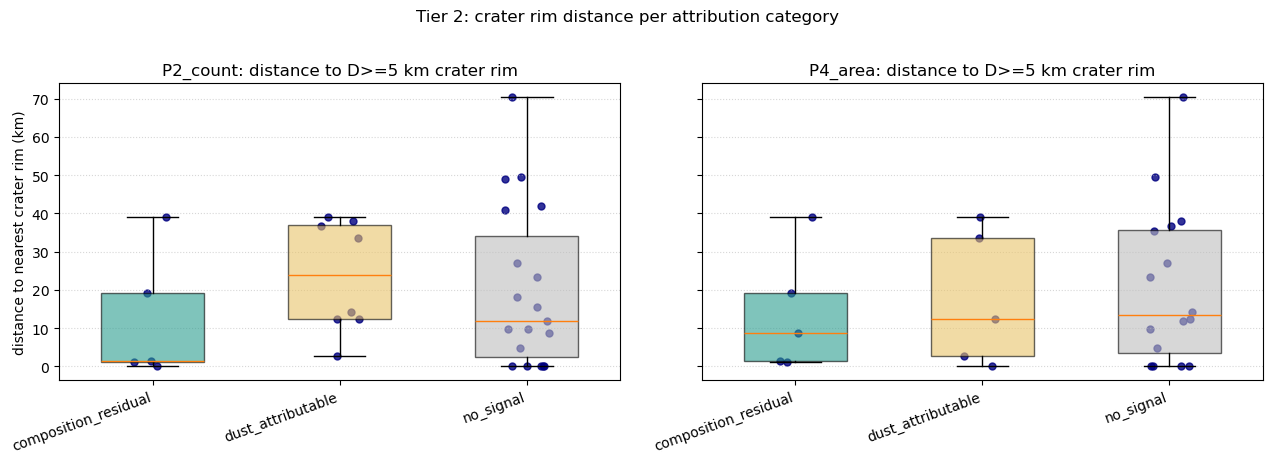

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
order = ["composition_residual", "dust_attributable", "no_signal"]
colors = {"composition_residual": "#2a9d8f", "dust_attributable": "#e9c46a",
          "no_signal": "#bdbdbd"}
for ax, sub, label in [(axes[0], sub_p2, "P2_count"),
                       (axes[1], sub_p4, "P4_area")]:
    data = [sub[sub["attribution"] == cat]["nearest_D>=5.0_km_rim"].dropna().to_numpy()
            for cat in order]
    bp = ax.boxplot(data, positions=range(len(order)), widths=0.55,
                    showfliers=False, patch_artist=True)
    for patch, cat in zip(bp["boxes"], order):
        patch.set_facecolor(colors[cat]); patch.set_alpha(0.6)
    for i, (d, cat) in enumerate(zip(data, order)):
        ax.scatter(np.full_like(d, i, dtype=float) + np.random.uniform(-0.12, 0.12, size=len(d)),
                   d, s=25, alpha=0.8, color="navy")
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=20, ha="right")
    ax.set_title(f"{label}: distance to D>=5 km crater rim")
    ax.grid(True, axis="y", linestyle=":", alpha=0.5)
axes[0].set_ylabel("distance to nearest crater rim (km)")
fig.suptitle("Tier 2: crater rim distance per attribution category",
             y=1.02)
fig.tight_layout()
fig.savefig(FIG / "stage7_tier2_crater_distance.png", dpi=140, bbox_inches="tight")
plt.show()


**Tier 2 verdict.** Crater distance does not significantly separate
the three attribution categories at any diameter threshold (Kruskal-Wallis
p > 0.8 across all tests). Mean distances overlap within 1 sigma.

The null is itself informative: under the crater-ejecta-source
interpretation, composition_residual images should have shown
significantly closer crater-rim distances. They do not. This **weakly
disfavours** the locally-sourced-from-crater-ejecta interpretation, but
does not directly support the transported interpretation either (the
test is symmetric; a non-correlation supports "crater-independent
mechanism" without specifying what the mechanism is).

Two caveats apply: (a) n = 5 in composition_residual gives low statistical
power; (b) image-center distance is a proxy, and tile-level analysis
within each footprint would refine but cannot easily lift the
power limitation.


## 4. Combined verdict

Tier 1 finds a statistically significant enrichment of `composition_residual`
on transport-indicator terrain (Fisher's exact OR = 12.0, p = 0.034 under
P2_count). Tier 2 finds no significant separation of `composition_residual`
on crater proximity (Kruskal-Wallis p > 0.8).

The two tests *together* most strongly support the **transported-with-
distinct-deposit-character interpretation** over the
**crater-ejecta-locally-sourced** interpretation, because:

1. Crater-ejecta-locally-sourced predicts a Tier 2 positive (crater
   proximity). We don't see it.
2. Transported-distinct-deposit predicts a Tier 1 positive (deposit-flag
   correlation). We see it at p = 0.034.

The **surface-maturity-locally-sourced** interpretation (boulders = fresh
version of the same regional parent rock as surrounding regolith, e.g.
from non-crater bedrock weathering) is NOT directly tested by Tier 1 or
Tier 2 and remains in play. Tier 3 (compare composition residual against
inferred upstream source-unit colour) would be needed to distinguish
transported-from-highland-source from regional-maturity-of-local-bedrock.

Caveats:

- **Small sample (n = 5 composition_residual)** in both tests; the Tier 1
  result is significant but marginal, and Tier 2 may be underpowered.
- **Brian's terrain annotations are single-rater**; a second annotator
  would strengthen Tier 1.
- **The 2 missing ObsIds** (ESP_017355_2260 in composition_residual,
  ESP_076499_1160 in no_signal) are scored `transport_indicator = False`
  which biases toward the null in Tier 1 -- the true effect may be
  stronger.
- **Robbins 2012 catalogues craters >= 1 km**; smaller secondaries and
  sub-km impacts (which could still produce local ejecta) are not
  captured. The Tier 2 null is robust to this only if the relevant
  ejecta source craters are >= 1 km.
- **Image-center vs tile-level** test resolution -- a tile-level
  partial-dust + crater-distance test inside each composition_residual
  image's footprint would be more rigorous but is not done here.

The compositional analysis at this wrap-up therefore lands with: a real
composition residual exists at the cohort level; it is preferentially
located on terrain Brian flags as depositional with transport
characteristics; it does not preferentially locate at crater-derived
ejecta blankets. **Modest empirical support for the transported-provenance
interpretation, well short of definitive proof.**
